In [1]:
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('bsbioactivity_prediction_data1.csv')

In [4]:
df

,SL NO,SMILES,IC50 (nM),P'CHEMBL,Canonical_smiles,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,...,atom_pair_fp_2039,atom_pair_fp_2040,atom_pair_fp_2041,atom_pair_fp_2042,atom_pair_fp_2043,atom_pair_fp_2044,atom_pair_fp_2045,atom_pair_fp_2046,atom_pair_fp_2047,activity
0,1,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cc(F)cc(...,2.6,8.585027,COC1CCC2(CC1)Cc1ccc(-c3cc(F)cc(Cl)c3)cc1C21N=C...,429.923,4.62210,1,5,60.08,...,0,0,0,0,0,1,1,0,0,active
1,2,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cc(Cl)cc...,3.5,8.455932,COC1CCC2(CC1)Cc1ccc(-c3cc(Cl)cc(C#N)c3)cc1C21N...,436.943,4.35468,1,6,83.87,...,0,1,0,0,0,1,1,0,0,active
2,3,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=C2)C#CC2CC2)CC1,4.5,8.346787,COC1CCC2(CC1)Cc1ccc(C#CC3CC3)cc1C21C=C(N)N(C)O1,364.489,3.45200,1,4,47.72,...,0,1,0,0,0,0,0,0,0,active
3,4,COC1CCC2(Cc3ccc(cc3C22C=C(N)N(C)C2=O)-c2cccc(c...,4.0,8.397940,COC1CCC2(CC1)Cc1ccc(-c3cccc(C#N)c3)cc1C21C=C(N...,413.521,3.86668,1,4,79.35,...,0,1,0,0,0,0,0,0,0,active
4,5,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cccc(Cl)...,4.5,8.346787,COC1CCC2(CC1)Cc1ccc(-c3cccc(Cl)c3)cc1C21N=C(N)...,411.933,4.48300,1,5,60.08,...,0,0,0,0,0,1,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,CO[C@H]1CC[C@@]2(Cc3ccc(cc3[C@]22N=C(N)N(CC3CO...,6.0,8.221849,CO[C@H]1CC[C@@]2(Cc3ccc(C#N)cc3[C@]23N=C(N)N(C...,438.528,1.70338,1,7,110.17,...,0,1,0,0,0,0,0,0,0,active
581,582,CO[C@H]1CCC2(Cc3ccc(cc3C22N=C(N)N(CC3CCCO3)C2=...,35.0,7.455932,COC1CCC2(CC1)Cc1ccc(C#N)cc1C21N=C(N)N(CC2CCCO2...,408.502,2.22098,1,6,100.94,...,0,1,0,0,0,0,0,0,0,active
582,583,COCCN1C(N)=NC2(C1=O)c1cc(ccc1C[C@@]21CC[C@@H](...,49.0,7.309804,COCCN1C(=O)C2(N=C1N)c1cc(C#N)ccc1C[C@]21CC[C@@...,382.464,1.68838,1,6,100.94,...,0,1,0,0,0,0,0,0,0,active
583,584,COC1CCC2(Cc3ccc(cc3C22N=C(N)N(C(C)C)C2=O)C#N)CC1,107.0,6.970616,COC1CCC2(CC1)Cc1ccc(C#N)cc1C21N=C(N)N(C(C)C)C1=O,366.465,2.45038,1,5,91.71,...,0,1,0,0,0,0,0,0,0,active


In [5]:
df.isnull().sum()

SL NO                0
 SMILES              0
IC50 (nM)            0
P'CHEMBL             0
Canonical_smiles     0
                    ..
atom_pair_fp_2044    0
atom_pair_fp_2045    0
atom_pair_fp_2046    0
atom_pair_fp_2047    0
activity             0
Length: 6323, dtype: int64

In [6]:
df = df.drop(columns=[col for col in df.columns 
                   if col.startswith(('maccs_fp_', 'atom_pair_fp_', 'pubchem_fp_'))])

In [7]:
df

,SL NO,SMILES,IC50 (nM),P'CHEMBL,Canonical_smiles,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,...,morgan_fp_2039,morgan_fp_2040,morgan_fp_2041,morgan_fp_2042,morgan_fp_2043,morgan_fp_2044,morgan_fp_2045,morgan_fp_2046,morgan_fp_2047,activity
0,1,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cc(F)cc(...,2.6,8.585027,COC1CCC2(CC1)Cc1ccc(-c3cc(F)cc(Cl)c3)cc1C21N=C...,429.923,4.62210,1,5,60.08,...,0,0,0,0,0,0,0,0,0,active
1,2,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cc(Cl)cc...,3.5,8.455932,COC1CCC2(CC1)Cc1ccc(-c3cc(Cl)cc(C#N)c3)cc1C21N...,436.943,4.35468,1,6,83.87,...,0,0,0,0,0,0,0,0,0,active
2,3,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=C2)C#CC2CC2)CC1,4.5,8.346787,COC1CCC2(CC1)Cc1ccc(C#CC3CC3)cc1C21C=C(N)N(C)O1,364.489,3.45200,1,4,47.72,...,0,0,0,0,0,0,0,0,0,active
3,4,COC1CCC2(Cc3ccc(cc3C22C=C(N)N(C)C2=O)-c2cccc(c...,4.0,8.397940,COC1CCC2(CC1)Cc1ccc(-c3cccc(C#N)c3)cc1C21C=C(N...,413.521,3.86668,1,4,79.35,...,0,0,0,0,0,0,0,0,0,active
4,5,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cccc(Cl)...,4.5,8.346787,COC1CCC2(CC1)Cc1ccc(-c3cccc(Cl)c3)cc1C21N=C(N)...,411.933,4.48300,1,5,60.08,...,0,0,0,0,0,0,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,CO[C@H]1CC[C@@]2(Cc3ccc(cc3[C@]22N=C(N)N(CC3CO...,6.0,8.221849,CO[C@H]1CC[C@@]2(Cc3ccc(C#N)cc3[C@]23N=C(N)N(C...,438.528,1.70338,1,7,110.17,...,0,0,0,0,0,0,0,0,0,active
581,582,CO[C@H]1CCC2(Cc3ccc(cc3C22N=C(N)N(CC3CCCO3)C2=...,35.0,7.455932,COC1CCC2(CC1)Cc1ccc(C#N)cc1C21N=C(N)N(CC2CCCO2...,408.502,2.22098,1,6,100.94,...,0,0,0,0,0,0,0,0,0,active
582,583,COCCN1C(N)=NC2(C1=O)c1cc(ccc1C[C@@]21CC[C@@H](...,49.0,7.309804,COCCN1C(=O)C2(N=C1N)c1cc(C#N)ccc1C[C@]21CC[C@@...,382.464,1.68838,1,6,100.94,...,0,0,0,0,0,0,0,0,0,active
583,584,COC1CCC2(Cc3ccc(cc3C22N=C(N)N(C(C)C)C2=O)C#N)CC1,107.0,6.970616,COC1CCC2(CC1)Cc1ccc(C#N)cc1C21N=C(N)N(C(C)C)C1=O,366.465,2.45038,1,5,91.71,...,0,0,0,0,0,0,0,0,0,active


In [8]:
# Calculate sum of each feature
feature_sum = df.sum()

# Find features with sum = 0
zero_features = feature_sum[feature_sum == 0].index

# Remove those features
df = df.drop(columns = zero_features)

print("Removed columns:", len(zero_features))

Removed columns: 977


In [9]:
df

,SL NO,SMILES,IC50 (nM),P'CHEMBL,Canonical_smiles,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,...,morgan_fp_2029,morgan_fp_2032,morgan_fp_2033,morgan_fp_2035,morgan_fp_2036,morgan_fp_2039,morgan_fp_2042,morgan_fp_2045,morgan_fp_2046,activity
0,1,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cc(F)cc(...,2.6,8.585027,COC1CCC2(CC1)Cc1ccc(-c3cc(F)cc(Cl)c3)cc1C21N=C...,429.923,4.62210,1,5,60.08,...,0,0,0,0,0,0,0,0,0,active
1,2,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cc(Cl)cc...,3.5,8.455932,COC1CCC2(CC1)Cc1ccc(-c3cc(Cl)cc(C#N)c3)cc1C21N...,436.943,4.35468,1,6,83.87,...,0,0,0,0,0,0,0,0,0,active
2,3,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=C2)C#CC2CC2)CC1,4.5,8.346787,COC1CCC2(CC1)Cc1ccc(C#CC3CC3)cc1C21C=C(N)N(C)O1,364.489,3.45200,1,4,47.72,...,0,0,0,0,0,0,0,0,0,active
3,4,COC1CCC2(Cc3ccc(cc3C22C=C(N)N(C)C2=O)-c2cccc(c...,4.0,8.397940,COC1CCC2(CC1)Cc1ccc(-c3cccc(C#N)c3)cc1C21C=C(N...,413.521,3.86668,1,4,79.35,...,0,0,0,0,0,0,0,0,0,active
4,5,COC1CCC2(Cc3ccc(cc3C22ON(C)C(N)=N2)-c2cccc(Cl)...,4.5,8.346787,COC1CCC2(CC1)Cc1ccc(-c3cccc(Cl)c3)cc1C21N=C(N)...,411.933,4.48300,1,5,60.08,...,0,0,0,0,0,0,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,CO[C@H]1CC[C@@]2(Cc3ccc(cc3[C@]22N=C(N)N(CC3CO...,6.0,8.221849,CO[C@H]1CC[C@@]2(Cc3ccc(C#N)cc3[C@]23N=C(N)N(C...,438.528,1.70338,1,7,110.17,...,0,0,0,0,0,0,0,0,0,active
581,582,CO[C@H]1CCC2(Cc3ccc(cc3C22N=C(N)N(CC3CCCO3)C2=...,35.0,7.455932,COC1CCC2(CC1)Cc1ccc(C#N)cc1C21N=C(N)N(CC2CCCO2...,408.502,2.22098,1,6,100.94,...,0,0,0,0,0,0,0,0,0,active
582,583,COCCN1C(N)=NC2(C1=O)c1cc(ccc1C[C@@]21CC[C@@H](...,49.0,7.309804,COCCN1C(=O)C2(N=C1N)c1cc(C#N)ccc1C[C@]21CC[C@@...,382.464,1.68838,1,6,100.94,...,0,0,0,0,0,0,0,0,0,active
583,584,COC1CCC2(Cc3ccc(cc3C22N=C(N)N(C(C)C)C2=O)C#N)CC1,107.0,6.970616,COC1CCC2(CC1)Cc1ccc(C#N)cc1C21N=C(N)N(C(C)C)C1=O,366.465,2.45038,1,5,91.71,...,0,0,0,0,0,0,0,0,0,active


In [10]:
df.columns

Index(['SL NO', ' SMILES', 'IC50 (nM)', 'P'CHEMBL ', 'Canonical_smiles',
       'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
       ...
       'morgan_fp_2029', 'morgan_fp_2032', 'morgan_fp_2033', 'morgan_fp_2035',
       'morgan_fp_2036', 'morgan_fp_2039', 'morgan_fp_2042', 'morgan_fp_2045',
       'morgan_fp_2046', 'activity'],
      dtype='object', length=1083)

In [11]:
df.columns = df.columns.str.strip()   # removes extra spaces
df.columns = df.columns.str.replace("'", "")  # removes unwanted quotes

In [12]:
df.columns

Index(['SL NO', 'SMILES', 'IC50 (nM)', 'PCHEMBL', 'Canonical_smiles', 'MolWt',
       'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
       ...
       'morgan_fp_2029', 'morgan_fp_2032', 'morgan_fp_2033', 'morgan_fp_2035',
       'morgan_fp_2036', 'morgan_fp_2039', 'morgan_fp_2042', 'morgan_fp_2045',
       'morgan_fp_2046', 'activity'],
      dtype='object', length=1083)

In [13]:
df = df.drop_duplicates(subset = [ 'SMILES', 'IC50 (nM)', 'PCHEMBL', 'Canonical_smiles'])

In [14]:
df.drop([ 'SMILES', 'IC50 (nM)', 'PCHEMBL', 'Canonical_smiles'], axis = 1, inplace = True)

In [15]:
df

,SL NO,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_1,morgan_fp_2,morgan_fp_3,...,morgan_fp_2029,morgan_fp_2032,morgan_fp_2033,morgan_fp_2035,morgan_fp_2036,morgan_fp_2039,morgan_fp_2042,morgan_fp_2045,morgan_fp_2046,activity
0,1,429.923,4.62210,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,active
1,2,436.943,4.35468,1,6,83.87,2,0,0,0,...,0,0,0,0,0,0,0,0,0,active
2,3,364.489,3.45200,1,4,47.72,1,0,0,0,...,0,0,0,0,0,0,0,0,0,active
3,4,413.521,3.86668,1,4,79.35,2,0,0,0,...,0,0,0,0,0,0,0,0,0,active
4,5,411.933,4.48300,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,438.528,1.70338,1,7,110.17,3,0,0,0,...,0,0,0,0,0,0,0,0,0,active
581,582,408.502,2.22098,1,6,100.94,3,0,0,0,...,0,0,0,0,0,0,0,0,0,active
582,583,382.464,1.68838,1,6,100.94,4,0,0,0,...,0,0,0,0,0,0,0,0,0,active
583,584,366.465,2.45038,1,5,91.71,2,1,0,0,...,0,0,0,0,0,0,0,0,0,active


In [16]:
df.rename(columns={'activity': 'target'}, inplace=True)

In [17]:
if df['target'].dtype == 'object':
    df['target'] = df['target'].str.strip().str.lower()
    df['target'] = df['target'].map({'active': 1, 'inactive': 0})

In [18]:
df.head()

,SL NO,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_1,morgan_fp_2,morgan_fp_3,...,morgan_fp_2029,morgan_fp_2032,morgan_fp_2033,morgan_fp_2035,morgan_fp_2036,morgan_fp_2039,morgan_fp_2042,morgan_fp_2045,morgan_fp_2046,target
0,1,429.923,4.62210,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,436.943,4.35468,1,6,83.87,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,364.489,3.45200,1,4,47.72,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,413.521,3.86668,1,4,79.35,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,411.933,4.48300,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [19]:
numeric_cols = ['MolWt', 'LogP', 'NumHDonors','NumHAcceptors', 'TPSA', 'RotatableBonds']

Outliers ={}
for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        IQR = Q3 - Q1
         
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR 
        
        Outliers[col]=df[(df[col]<lower)| (df[col]>upper)]
        
        print (f"{col} : {len(Outliers [col])} outlier detected")

MolWt : 11 outlier detected
LogP : 5 outlier detected
NumHDonors : 61 outlier detected
NumHAcceptors : 0 outlier detected
TPSA : 9 outlier detected
RotatableBonds : 1 outlier detected


In [20]:
df = df[(df[col] >= lower) & (df[col] <= upper)]
df

,SL NO,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_1,morgan_fp_2,morgan_fp_3,...,morgan_fp_2029,morgan_fp_2032,morgan_fp_2033,morgan_fp_2035,morgan_fp_2036,morgan_fp_2039,morgan_fp_2042,morgan_fp_2045,morgan_fp_2046,target
0,1,429.923,4.62210,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,436.943,4.35468,1,6,83.87,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,364.489,3.45200,1,4,47.72,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,413.521,3.86668,1,4,79.35,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,411.933,4.48300,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,438.528,1.70338,1,7,110.17,3,0,0,0,...,0,0,0,0,0,0,0,0,0,1
581,582,408.502,2.22098,1,6,100.94,3,0,0,0,...,0,0,0,0,0,0,0,0,0,1
582,583,382.464,1.68838,1,6,100.94,4,0,0,0,...,0,0,0,0,0,0,0,0,0,1
583,584,366.465,2.45038,1,5,91.71,2,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [21]:
# Step 1: remove non-numeric
df_numeric = df.select_dtypes(include=['number'])

# Step 2: remove constant features
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# Step 3: correlation
correlation_matrix = df_numeric.corr()

In [22]:
correlated_fetaures = set()
correlation_matrix = df_numeric.corr()

In [23]:
for i in range(len(correlation_matrix. columns)):
    for j in range (i):
        if abs(correlation_matrix.iloc[i,j]) > 0.8:
            colname = correlation_matrix.columns[i]
            correlated_fetaures.add(colname)

In [24]:
df.drop(labels =correlated_fetaures, axis =1, inplace = True)

C:\Users\dell\AppData\Local\Temp\ipykernel_812\3545864747.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(labels =correlated_fetaures, axis =1, inplace = True)


In [25]:
df

,SL NO,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_1,morgan_fp_2,morgan_fp_3,...,morgan_fp_1985,morgan_fp_1993,morgan_fp_1994,morgan_fp_1998,morgan_fp_2003,morgan_fp_2009,morgan_fp_2032,morgan_fp_2033,morgan_fp_2039,target
0,1,429.923,4.62210,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,436.943,4.35468,1,6,83.87,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,364.489,3.45200,1,4,47.72,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,413.521,3.86668,1,4,79.35,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,411.933,4.48300,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,438.528,1.70338,1,7,110.17,3,0,0,0,...,0,0,0,0,0,0,0,0,0,1
581,582,408.502,2.22098,1,6,100.94,3,0,0,0,...,0,0,0,0,0,0,0,0,0,1
582,583,382.464,1.68838,1,6,100.94,4,0,0,0,...,0,0,0,0,0,0,0,0,0,1
583,584,366.465,2.45038,1,5,91.71,2,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [26]:
X = df.iloc [:,:-1]
y = df.target

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42, stratify = y)

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
df

,SL NO,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_1,morgan_fp_2,morgan_fp_3,...,morgan_fp_1985,morgan_fp_1993,morgan_fp_1994,morgan_fp_1998,morgan_fp_2003,morgan_fp_2009,morgan_fp_2032,morgan_fp_2033,morgan_fp_2039,target
0,1,429.923,4.62210,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,436.943,4.35468,1,6,83.87,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,364.489,3.45200,1,4,47.72,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,413.521,3.86668,1,4,79.35,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,411.933,4.48300,1,5,60.08,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,581,438.528,1.70338,1,7,110.17,3,0,0,0,...,0,0,0,0,0,0,0,0,0,1
581,582,408.502,2.22098,1,6,100.94,3,0,0,0,...,0,0,0,0,0,0,0,0,0,1
582,583,382.464,1.68838,1,6,100.94,4,0,0,0,...,0,0,0,0,0,0,0,0,0,1
583,584,366.465,2.45038,1,5,91.71,2,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [31]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from imblearn.over_sampling import SMOTE

# ensure clean data
X_train = X_train.select_dtypes(include=['number']).fillna(0)
y_train = y_train.astype(int)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [32]:
smote = SMOTE(random_state = 42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [33]:
y_train_sm.value_counts()

target
1    444
0    444
Name: count, dtype: int64

In [34]:
import matplotlib.pyplot as plt

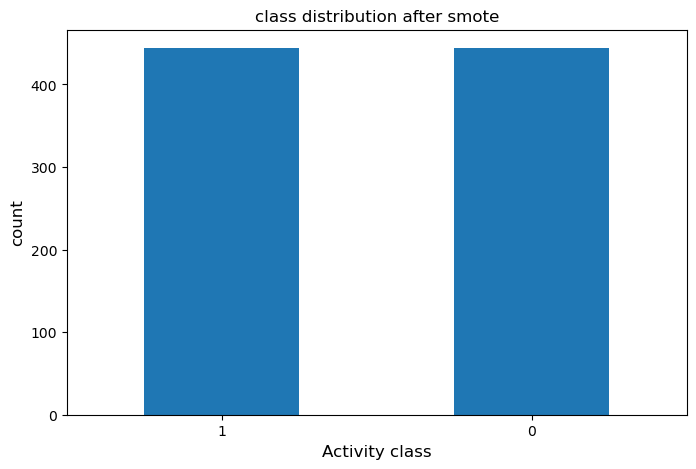

In [35]:
plt.figure(figsize =(8,5))
y_train_sm.value_counts().plot(kind ="bar")
plt.title ("class distribution after smote", fontsize= 12)
plt.xlabel("Activity class", fontsize= 12)
plt.ylabel("count", fontsize= 12)
plt.xticks(rotation=0)
plt.show()

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier


In [37]:
RF = RandomForestClassifier(random_state = 42)
RF.fit(X_train_sm, y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
RF_predict = RF.predict(X_test)

In [39]:
print('Accuracy_score =', (accuracy_score(y_test, RF_predict)))

print(classification_report(y_test, RF_predict))

Accuracy_score = 0.9572649572649573
              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.96      0.99      0.98       111

    accuracy                           0.96       117
   macro avg       0.82      0.66      0.71       117
weighted avg       0.95      0.96      0.95       117



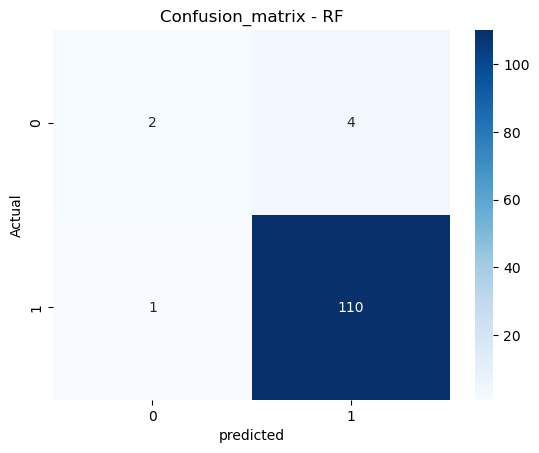

In [40]:
cm = confusion_matrix(y_test, RF_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix - RF")
plt.show()

In [41]:
from sklearn.metrics import roc_curve, auc

RF ROC AUC = 0.904


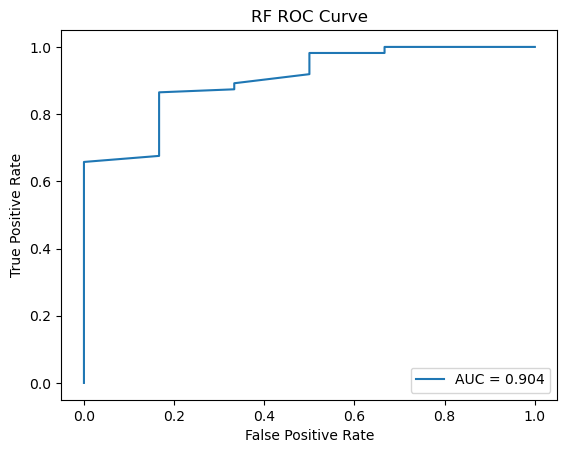

In [42]:

# Probability prediction 
RF_prob = RF.predict_proba(X_test)[:, 1]

# ROC calculation
fpr1, tpr1, threshold = roc_curve(y_test, RF_prob, pos_label=1)
roc_auc = auc(fpr1, tpr1)

# Plot ROC curve
plt.title('RF ROC Curve')
plt.plot(fpr1, tpr1, label='AUC = %0.3f' % roc_auc)
plt.legend(loc="lower right")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

print('RF ROC AUC = %0.3f' % roc_auc)

plt.show()

In [43]:
from xgboost import XGBClassifier
import xgboost as xgb

In [44]:
xg = xgb.XGBClassifier()
xg.fit(X_train_sm, y_train_sm)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [45]:
xg_predict = xg.predict(X_test)

In [46]:
print('Accuracy_score =', (accuracy_score(y_test, xg_predict)))

print(classification_report(y_test, xg_predict))

Accuracy_score = 0.9316239316239316
              precision    recall  f1-score   support

           0       0.38      0.50      0.43         6
           1       0.97      0.95      0.96       111

    accuracy                           0.93       117
   macro avg       0.67      0.73      0.70       117
weighted avg       0.94      0.93      0.94       117



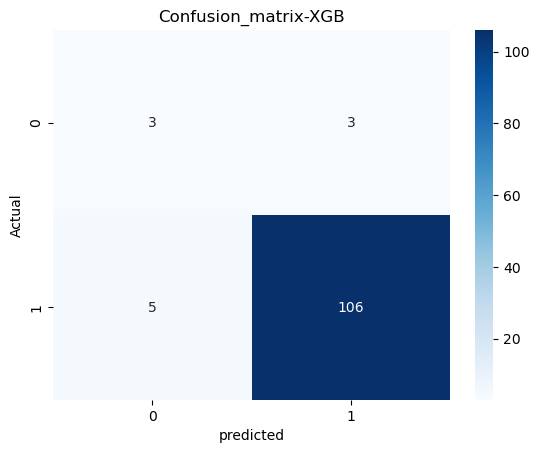

In [47]:
cm = confusion_matrix(y_test, xg_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix-XGB")
plt.show()

XGB ROC AUC = 0.890


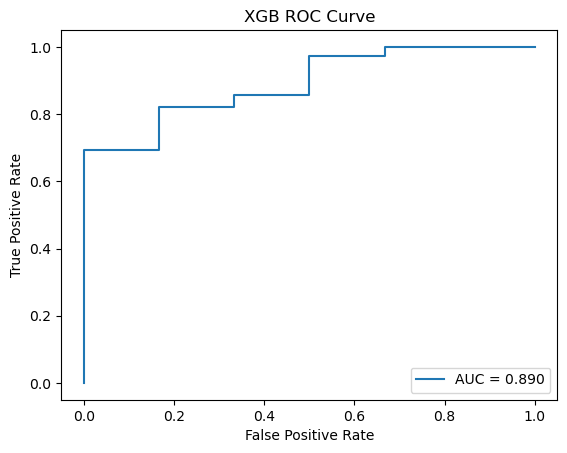

In [48]:
XGB_prob = xg.predict_proba(X_test)[:, 1]

# ROC calculation
fpr1, tpr1, threshold = roc_curve(y_test, XGB_prob, pos_label=1)
roc_auc = auc(fpr1, tpr1)

# Plot ROC curve
plt.title('XGB ROC Curve')
plt.plot(fpr1, tpr1, label='AUC = %0.3f' % roc_auc)
plt.legend(loc="lower right")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

print('XGB ROC AUC = %0.3f' % roc_auc)

plt.show()

In [49]:
LR = LogisticRegression()
LR.fit(X_train_sm, y_train_sm)

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [50]:
LogisticRegression()

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [51]:
LR_predict = LR.predict(X_test)

In [52]:
print('Accuracy_score =', (accuracy_score(y_test, LR_predict)))

print(classification_report(y_test, LR_predict))

Accuracy_score = 0.9145299145299145
              precision    recall  f1-score   support

           0       0.17      0.17      0.17         6
           1       0.95      0.95      0.95       111

    accuracy                           0.91       117
   macro avg       0.56      0.56      0.56       117
weighted avg       0.91      0.91      0.91       117



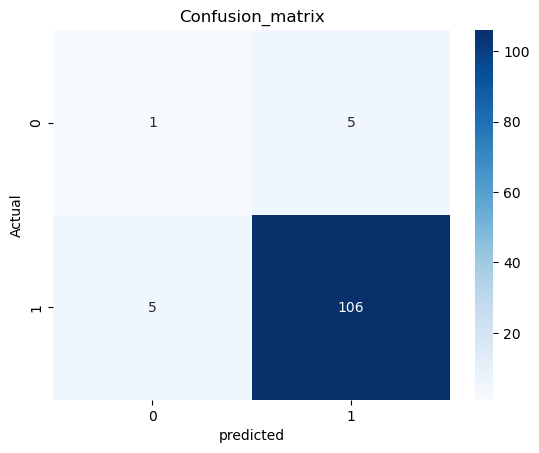

In [53]:
cm = confusion_matrix(y_test, LR_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix")
plt.show()

LR ROC AUC = 0.868


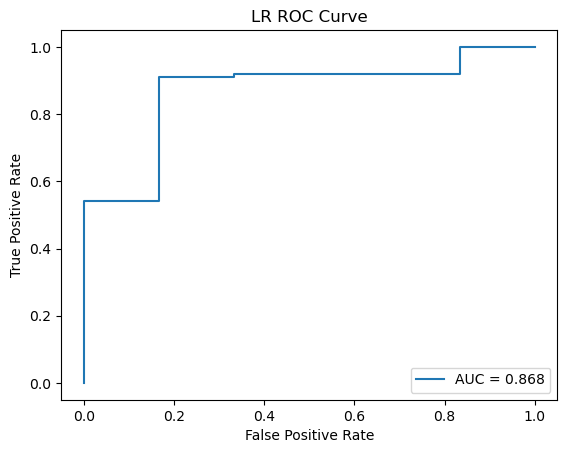

In [54]:
LR_prob = LR.predict_proba(X_test)[:, 1]
fpr1, tpr1, threshold = roc_curve(y_test, LR_prob, pos_label=1)
roc_auc = auc(fpr1, tpr1)

plt.title('LR ROC Curve')
plt.plot(fpr1, tpr1, label='AUC = %0.3f' % roc_auc)
plt.legend(loc="lower right")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

print('LR ROC AUC = %0.3f' % roc_auc)

plt.show()

In [55]:
DT = DecisionTreeClassifier(criterion ='gini', random_state=42)
DT.fit(X_train_sm, y_train_sm)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [56]:
DT_predict = DT.predict(X_test)

In [57]:
print('Accuracy_score =', (accuracy_score(y_test, DT_predict)))

print(classification_report(y_test, DT_predict))

Accuracy_score = 0.9145299145299145
              precision    recall  f1-score   support

           0       0.30      0.50      0.38         6
           1       0.97      0.94      0.95       111

    accuracy                           0.91       117
   macro avg       0.64      0.72      0.66       117
weighted avg       0.94      0.91      0.92       117



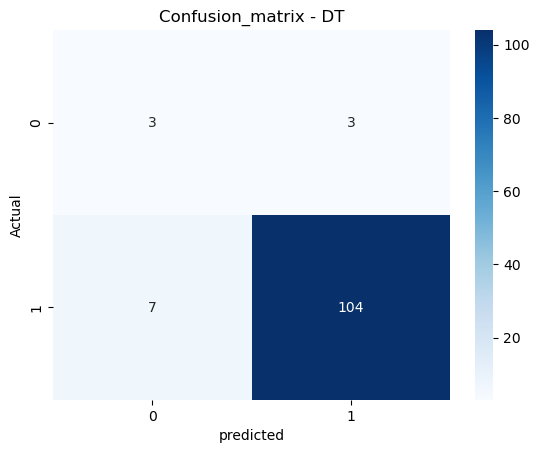

In [58]:
cm = confusion_matrix(y_test, DT_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix - DT")
plt.show()

DT ROC AUC = 0.718


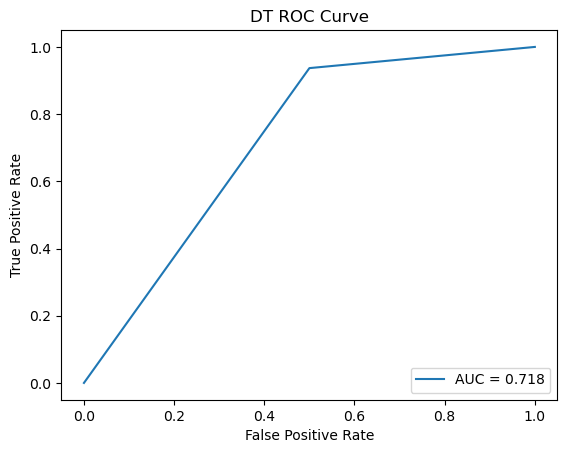

In [59]:
# Probability prediction 
DT_prob = DT.predict_proba(X_test)[:, 1]

# ROC calculation
fpr1, tpr1, threshold = roc_curve(y_test, DT_prob, pos_label=1)
roc_auc = auc(fpr1, tpr1)

# Plot ROC curve
plt.title('DT ROC Curve')
plt.plot(fpr1, tpr1, label='AUC = %0.3f' % roc_auc)
plt.legend(loc="lower right")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

y_pred = (LR_prob >= 0.3).astype(int)
print('DT ROC AUC = %0.3f' % roc_auc)

plt.show()

In [60]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_sm, y_train_sm)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [62]:
gb_predict = gb.predict(X_test)

In [63]:
print('Accuracy_score = ', accuracy_score(y_test, gb_predict))
print(classification_report(y_test, gb_predict))

Accuracy_score =  0.9487179487179487
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.97      0.97      0.97       111

    accuracy                           0.95       117
   macro avg       0.74      0.74      0.74       117
weighted avg       0.95      0.95      0.95       117



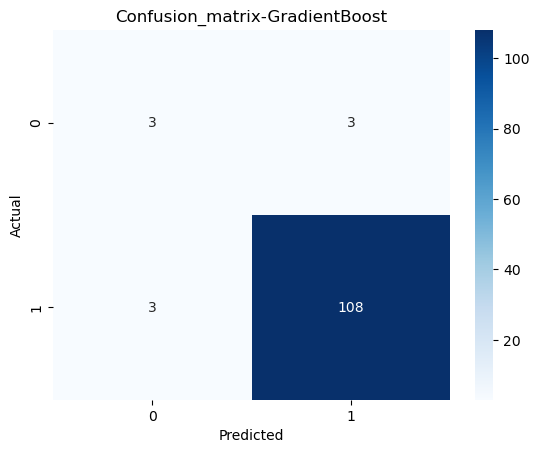

In [64]:
cm = confusion_matrix(y_test, gb_predict)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix-GradientBoost")
plt.show()

Gradient Boost ROC AUC = 0.920


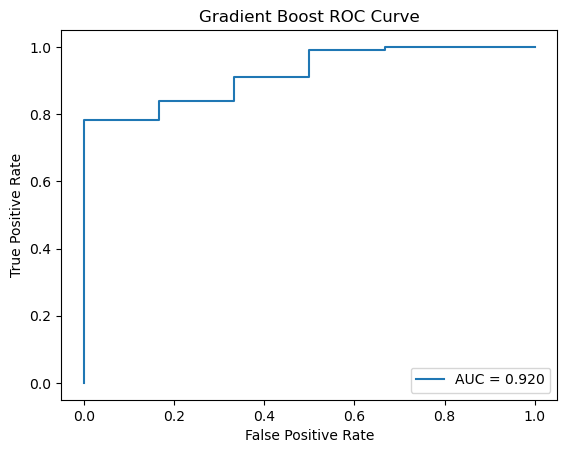

In [65]:
GB_prob = gb.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, GB_prob)
roc_auc = auc(fpr, tpr)

plt.title('Gradient Boost ROC Curve')
plt.plot(fpr, tpr, label='AUC = %0.3f' % roc_auc)
plt.legend(loc='lower right')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

print('Gradient Boost ROC AUC = %0.3f' % roc_auc)

plt.show()

In [66]:
SV = svm.SVC(probability=True)
SV.fit(X_train_sm, y_train_sm)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
SV_predict = SV.predict(X_test)

In [68]:
print('Accuracy_score =', (accuracy_score(y_test, SV_predict)))

print(classification_report(y_test, SV_predict))

Accuracy_score = 0.5384615384615384
              precision    recall  f1-score   support

           0       0.06      0.50      0.10         6
           1       0.95      0.54      0.69       111

    accuracy                           0.54       117
   macro avg       0.50      0.52      0.39       117
weighted avg       0.91      0.54      0.66       117



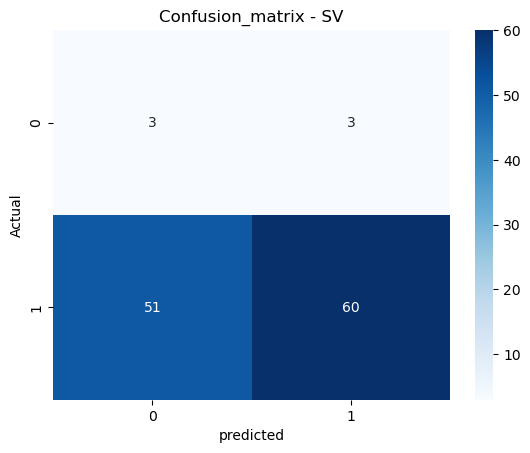

In [69]:
cm = confusion_matrix(y_test, SV_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix - SV")
plt.show()

SV ROC AUC = 0.526


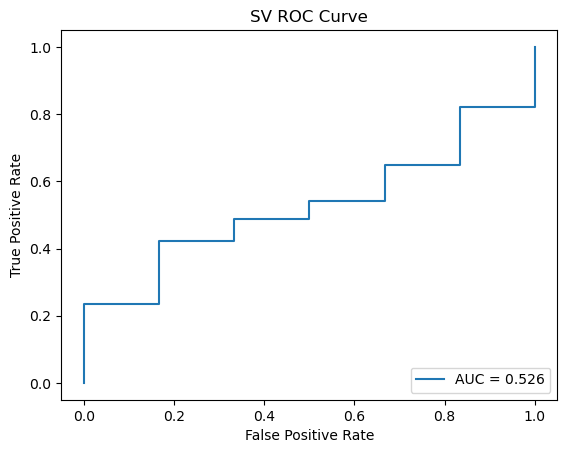

In [70]:
# Probability prediction 
SV_prob = SV.predict_proba(X_test)[:, 1]

# ROC calculation
fpr1, tpr1, threshold = roc_curve(y_test, SV_prob, pos_label=1)
roc_auc = auc(fpr1, tpr1)

# Plot ROC curve
plt.title('SV ROC Curve')
plt.plot(fpr1, tpr1, label='AUC = %0.3f' % roc_auc)
plt.legend(loc="lower right")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

print('SV ROC AUC = %0.3f' % roc_auc)

plt.show()

In [71]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from numpy import mean
from numpy import std

In [72]:
rfecv = RFECV(
    estimator = RandomForestClassifier(),
    step = 10,     # remove 10 features at each iteration
    cv = StratifiedKFold (5)
)
rfecv.fit(X_train_sm, y_train_sm)

,estimator,RandomForestClassifier()
,step,10
,min_features_to_select,1
,cv,StratifiedKFo...shuffle=False)
,scoring,None
,verbose,0
,n_jobs,None
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None


In [73]:
print ("optimal no. features:", rfecv.n_features_)

optimal no. features: 122


In [74]:
# Selected features

Selected_features = X_train.columns[rfecv.support_]

print("Selected Features:")
print(Selected_features)
pd.Series(Selected_features).to_csv("rfecv_feature_list.csv", index=False)

Selected Features:
Index(['SL NO', 'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
       'RotatableBonds', 'morgan_fp_1', 'morgan_fp_13', 'morgan_fp_15',
       ...
       'morgan_fp_1866', 'morgan_fp_1910', 'morgan_fp_1917', 'morgan_fp_1922',
       'morgan_fp_1923', 'morgan_fp_1928', 'morgan_fp_1941', 'morgan_fp_1954',
       'morgan_fp_1966', 'morgan_fp_1972'],
      dtype='object', length=122)


In [75]:
# To apply the selected features

X_train_rfecv = rfecv.transform(X_train_sm)
X_test_rfecv = rfecv.transform(X_test)

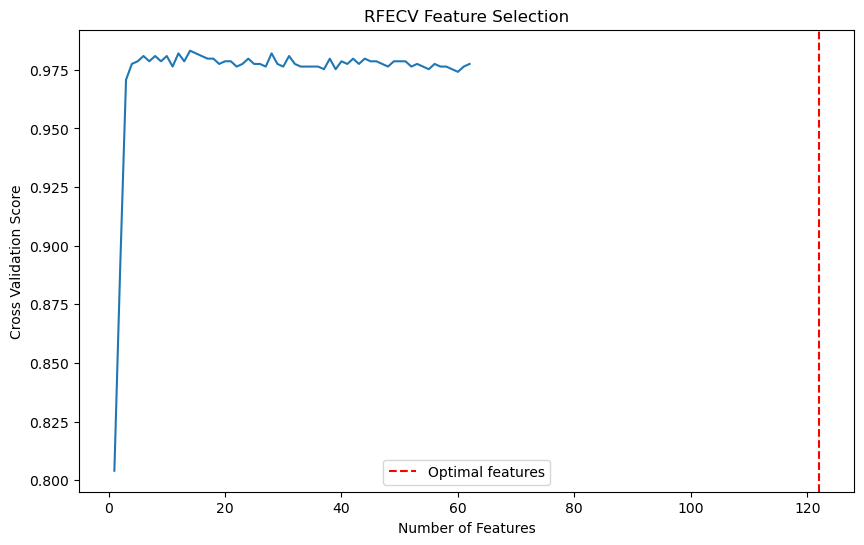

In [76]:
scores = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(10,6))
plt.plot(range(1, len(scores)+1), scores)
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label='Optimal features')
plt.xlabel("Number of Features")
plt.ylabel("Cross Validation Score")
plt.title("RFECV Feature Selection")
plt.legend()
plt.show()

In [77]:
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [78]:
def objective (trial):
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 1, 50),
        
    }
    
    model = RandomForestClassifier(**param, random_state = 42)
    model.fit(X_train_rfecv, y_train_sm)       # Parameters taken directly from RFECV selected features
    preds = model.predict(X_test_rfecv)
    accuracy = accuracy_score (y_test, preds)
    
    return accuracy

In [79]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)

best_trial = study.best_trial

print("Best Accuracy:", best_trial.value)
print("Best Parameters:", best_trial.params)

[I 2026-06-23 12:44:03,870] A new study created in memory with name: no-name-14faa3bd-9f74-446a-af56-42d8a64fd52d
[I 2026-06-23 12:44:04,363] Trial 0 finished with value: 0.9487179487179487 and parameters: {'n_estimators': 80, 'max_depth': 10}. Best is trial 0 with value: 0.9487179487179487.
[I 2026-06-23 12:44:04,712] Trial 1 finished with value: 0.9487179487179487 and parameters: {'n_estimators': 59, 'max_depth': 6}. Best is trial 0 with value: 0.9487179487179487.
[I 2026-06-23 12:44:05,083] Trial 2 finished with value: 0.9487179487179487 and parameters: {'n_estimators': 47, 'max_depth': 27}. Best is trial 0 with value: 0.9487179487179487.
[I 2026-06-23 12:44:05,223] Trial 3 finished with value: 0.9658119658119658 and parameters: {'n_estimators': 15, 'max_depth': 41}. Best is trial 3 with value: 0.9658119658119658.
[I 2026-06-23 12:44:05,603] Trial 4 finished with value: 0.9487179487179487 and parameters: {'n_estimators': 46, 'max_depth': 35}. Best is trial 3 with value: 0.9658119658

Best Accuracy: 0.9658119658119658
Best Parameters: {'n_estimators': 15, 'max_depth': 41}


In [80]:
rf_best = RandomForestClassifier(
    n_estimators=40,
    max_depth=43,
    random_state=42
)

In [81]:
rf_best.fit(X_train_rfecv, y_train_sm)

,n_estimators,40
,criterion,'gini'
,max_depth,43
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
rf_best_predict = rf_best.predict(X_test_rfecv)

In [83]:
# Accuracy Socre and Classification report

print('Accuracy_score =', (accuracy_score(y_test, rf_best_predict)))

print(classification_report(y_test, rf_best_predict))

Accuracy_score = 0.9572649572649573
              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.96      0.99      0.98       111

    accuracy                           0.96       117
   macro avg       0.82      0.66      0.71       117
weighted avg       0.95      0.96      0.95       117



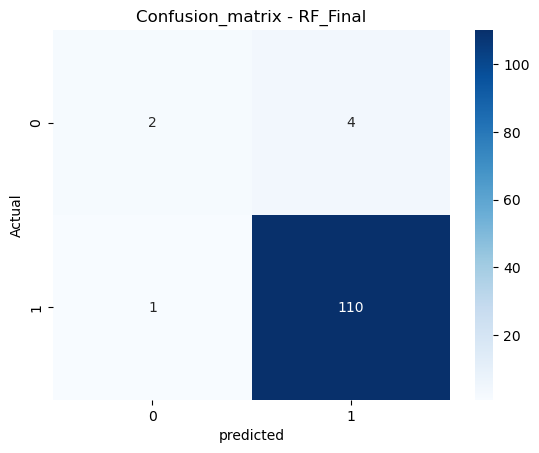

In [84]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_best_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix - RF_Final")
plt.show()

In [85]:
from sklearn.model_selection import cross_val_score,KFold

kf=KFold(n_splits=5, random_state=42,shuffle=True)
score=cross_val_score(rf_best,X_train_rfecv,y_train_sm,cv=kf)
print("Cross Validation Scores are {}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

Cross Validation Scores are [0.97752809 0.97752809 1.         0.96610169 0.98870056]
Average Cross Validation score :0.9819716879324574


In [86]:
gb_best = GradientBoostingClassifier(
    n_estimators=40,
    max_depth=43,
    random_state=42
)

In [87]:
gb_best.fit(X_train_rfecv, y_train_sm)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,40
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,43
,min_impurity_decrease,0.0
,init,None


In [88]:
gb_best_predict = gb_best.predict(X_test_rfecv)

In [89]:
# Accuracy Socre and Classification report

print('Accuracy_score =', (accuracy_score(y_test, gb_best_predict)))

print(classification_report(y_test, gb_best_predict))

Accuracy_score = 0.9230769230769231
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         6
           1       0.97      0.95      0.96       111

    accuracy                           0.92       117
   macro avg       0.65      0.72      0.68       117
weighted avg       0.94      0.92      0.93       117



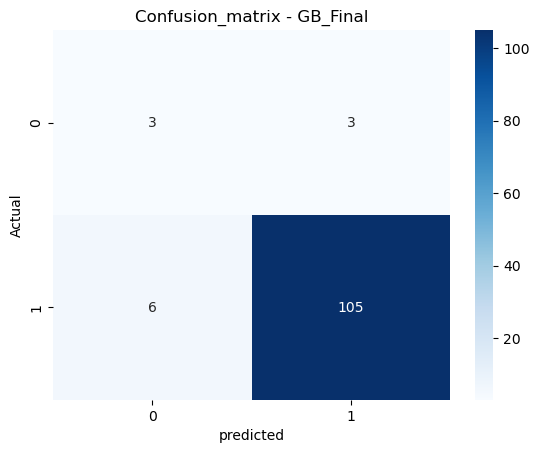

In [90]:
# Confusion matrix

cm = confusion_matrix(y_test, gb_best_predict)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix - GB_Final")
plt.show()

In [91]:
from sklearn.model_selection import cross_val_score,KFold

kf=KFold(n_splits=5, random_state=42,shuffle=True)
score=cross_val_score(gb_best,X_train_rfecv,y_train_sm,cv=kf)
print("Cross Validation Scores are {}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

Cross Validation Scores are [0.97752809 0.96629213 0.98876404 0.93785311 0.94350282]
Average Cross Validation score :0.9627880403732624


In [92]:
df_ext = pd.read_csv('external_flavonoids_bioactivity_prediction_data.csv')
df_ext.head()

,canonical_smiles,canonical_smiles.1,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_0,morgan_fp_1,...,atom_pair_fp_2038,atom_pair_fp_2039,atom_pair_fp_2040,atom_pair_fp_2041,atom_pair_fp_2042,atom_pair_fp_2043,atom_pair_fp_2044,atom_pair_fp_2045,atom_pair_fp_2046,atom_pair_fp_2047
0,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](OC3=CC(O)=C4C(=...,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](OC3=CC(O)=C4C(=...,580.539,-1.1652,8,14,225.06,6,0,0,...,0,0,1,1,0,0,0,0,0,0
1,CC(=O)OC[C@H]1O[C@@H](O[C@H]2[C@H](OC3=CC(O)=C...,CC(=O)OC[C@H]1O[C@@H](O[C@H]2[C@H](OC3=CC(O)=C...,710.594,-1.5731,9,19,301.80,9,0,0,...,0,0,1,1,1,0,0,0,0,0
2,CCOC(=O)[C@H]1O[C@@H](OC2=C(C3=CC=C(O)C(O)=C3)...,CCOC(=O)[C@H]1O[C@@H](OC2=C(C3=CC=C(O)C(O)=C3)...,506.416,0.0319,7,13,216.58,5,0,0,...,0,0,0,0,0,0,0,0,0,0
3,COC1=CC(O)=C2C(=O)C=C(C3=CC=CC=C3O[C@@H]3O[C@H...,COC1=CC(O)=C2C(=O)C=C(C3=CC=CC=C3O[C@@H]3O[C@H...,488.445,0.9237,4,11,165.12,6,0,0,...,0,0,1,1,0,0,0,0,0,0
4,COC(=O)C[N@+]1(C)CCC2=C(C1)C(OC)=C1OCOC1=C2C(=...,COC(=O)C[N@+]1(C)CCC2=C(C1)C(OC)=C1OCOC1=C2C(=...,484.525,3.0129,0,8,89.52,8,0,0,...,0,0,0,0,0,0,0,0,0,0


In [93]:
df.columns

Index(['SL NO', 'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
       'RotatableBonds', 'morgan_fp_1', 'morgan_fp_2', 'morgan_fp_3',
       ...
       'morgan_fp_1985', 'morgan_fp_1993', 'morgan_fp_1994', 'morgan_fp_1998',
       'morgan_fp_2003', 'morgan_fp_2009', 'morgan_fp_2032', 'morgan_fp_2033',
       'morgan_fp_2039', 'target'],
      dtype='object', length=603)

In [94]:
# Removing other Fingerprints

df_ext = df_ext.drop(columns=[col for col in df_ext.columns 
                   if col.startswith(('maccs_fp_', 'atom_pair_fp', 'pubchem_fp'))])

In [95]:
df_ext

,canonical_smiles,canonical_smiles.1,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_0,morgan_fp_1,...,morgan_fp_2038,morgan_fp_2039,morgan_fp_2040,morgan_fp_2041,morgan_fp_2042,morgan_fp_2043,morgan_fp_2044,morgan_fp_2045,morgan_fp_2046,morgan_fp_2047
0,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](OC3=CC(O)=C4C(=...,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](OC3=CC(O)=C4C(=...,580.539,-1.1652,8,14,225.06,6,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CC(=O)OC[C@H]1O[C@@H](O[C@H]2[C@H](OC3=CC(O)=C...,CC(=O)OC[C@H]1O[C@@H](O[C@H]2[C@H](OC3=CC(O)=C...,710.594,-1.5731,9,19,301.80,9,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CCOC(=O)[C@H]1O[C@@H](OC2=C(C3=CC=C(O)C(O)=C3)...,CCOC(=O)[C@H]1O[C@@H](OC2=C(C3=CC=C(O)C(O)=C3)...,506.416,0.0319,7,13,216.58,5,0,0,...,0,0,0,0,0,0,0,0,0,0
3,COC1=CC(O)=C2C(=O)C=C(C3=CC=CC=C3O[C@@H]3O[C@H...,COC1=CC(O)=C2C(=O)C=C(C3=CC=CC=C3O[C@@H]3O[C@H...,488.445,0.9237,4,11,165.12,6,0,0,...,0,0,0,0,0,0,0,0,0,0
4,COC(=O)C[N@+]1(C)CCC2=C(C1)C(OC)=C1OCOC1=C2C(=...,COC(=O)C[N@+]1(C)CCC2=C(C1)C(OC)=C1OCOC1=C2C(=...,484.525,3.0129,0,8,89.52,8,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38677,CC(=O)O[C@H]1[C@@H]2C3=C(C=CC4=C3O[C@@H](C3=CC...,CC(=O)O[C@H]1[C@@H]2C3=C(C=CC4=C3O[C@@H](C3=CC...,394.423,3.9357,0,6,71.06,2,0,0,...,0,0,0,0,0,0,0,0,0,0
38678,O=C1C(O[C@@H]2OC[C@H](O)[C@H](O)[C@H]2O)=C(C2=...,O=C1C(O[C@@H]2OC[C@H](O)[C@H](O)[C@H]2O)=C(C2=...,434.353,0.1002,7,11,190.28,3,0,0,...,0,0,0,0,0,0,0,0,0,0
38679,OC[C@H]1O[C@@H](OC2=C3C=C(C4=CC=C(O)C(O)=C4)OC...,OC[C@H]1O[C@@H](OC2=C3C=C(C4=CC=C(O)C(O)=C4)OC...,713.621,0.4414,11,16,279.98,7,0,0,...,0,0,0,0,0,0,0,0,0,0
38680,CN1C(O)=C(C(=O)/C=C/C[C@@H](C2=CC=CC=C2)N(C2=C...,CN1C(O)=C(C(=O)/C=C/C[C@@H](C2=CC=CC=C2)N(C2=C...,500.598,6.9527,1,4,62.54,8,0,1,...,0,0,0,0,0,0,0,0,0,0


In [96]:
df_ext = df_ext.loc[:, ~df_ext.columns.duplicated()]

In [97]:
df_ext = df_ext.drop(columns=['canonical_smiles.1', 'mol.1','mol'], errors='ignore')

In [98]:
df_ext = df_ext.reset_index(drop=True)

In [99]:
df_ext

,canonical_smiles,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_0,morgan_fp_1,morgan_fp_2,...,morgan_fp_2038,morgan_fp_2039,morgan_fp_2040,morgan_fp_2041,morgan_fp_2042,morgan_fp_2043,morgan_fp_2044,morgan_fp_2045,morgan_fp_2046,morgan_fp_2047
0,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](OC3=CC(O)=C4C(=...,580.539,-1.1652,8,14,225.06,6,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CC(=O)OC[C@H]1O[C@@H](O[C@H]2[C@H](OC3=CC(O)=C...,710.594,-1.5731,9,19,301.80,9,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CCOC(=O)[C@H]1O[C@@H](OC2=C(C3=CC=C(O)C(O)=C3)...,506.416,0.0319,7,13,216.58,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,COC1=CC(O)=C2C(=O)C=C(C3=CC=CC=C3O[C@@H]3O[C@H...,488.445,0.9237,4,11,165.12,6,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,COC(=O)C[N@+]1(C)CCC2=C(C1)C(OC)=C1OCOC1=C2C(=...,484.525,3.0129,0,8,89.52,8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38677,CC(=O)O[C@H]1[C@@H]2C3=C(C=CC4=C3O[C@@H](C3=CC...,394.423,3.9357,0,6,71.06,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38678,O=C1C(O[C@@H]2OC[C@H](O)[C@H](O)[C@H]2O)=C(C2=...,434.353,0.1002,7,11,190.28,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38679,OC[C@H]1O[C@@H](OC2=C3C=C(C4=CC=C(O)C(O)=C4)OC...,713.621,0.4414,11,16,279.98,7,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38680,CN1C(O)=C(C(=O)/C=C/C[C@@H](C2=CC=CC=C2)N(C2=C...,500.598,6.9527,1,4,62.54,8,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [100]:
if "SL NO" not in df_ext.columns:
    df_ext.insert(0, "SL NO", range(1, len(df_ext) + 1))
    print("'SL NO' column added successfully.")
else:
    print("'SL NO' column already exists.")

# Verify
print("\nFirst 5 rows:")
print(df_ext[["SL NO"]].head())

print("\nTotal columns:", len(df_ext.columns))
print("'SL NO' present:", "SL NO" in df_ext.columns)

'SL NO' column added successfully.

First 5 rows:
   SL NO
0      1
1      2
2      3
3      4
4      5

Total columns: 2056
'SL NO' present: True


In [101]:
df_ext

,SL NO,canonical_smiles,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_0,morgan_fp_1,...,morgan_fp_2038,morgan_fp_2039,morgan_fp_2040,morgan_fp_2041,morgan_fp_2042,morgan_fp_2043,morgan_fp_2044,morgan_fp_2045,morgan_fp_2046,morgan_fp_2047
0,1,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](OC3=CC(O)=C4C(=...,580.539,-1.1652,8,14,225.06,6,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,CC(=O)OC[C@H]1O[C@@H](O[C@H]2[C@H](OC3=CC(O)=C...,710.594,-1.5731,9,19,301.80,9,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,CCOC(=O)[C@H]1O[C@@H](OC2=C(C3=CC=C(O)C(O)=C3)...,506.416,0.0319,7,13,216.58,5,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,COC1=CC(O)=C2C(=O)C=C(C3=CC=CC=C3O[C@@H]3O[C@H...,488.445,0.9237,4,11,165.12,6,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,COC(=O)C[N@+]1(C)CCC2=C(C1)C(OC)=C1OCOC1=C2C(=...,484.525,3.0129,0,8,89.52,8,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38677,38678,CC(=O)O[C@H]1[C@@H]2C3=C(C=CC4=C3O[C@@H](C3=CC...,394.423,3.9357,0,6,71.06,2,0,0,...,0,0,0,0,0,0,0,0,0,0
38678,38679,O=C1C(O[C@@H]2OC[C@H](O)[C@H](O)[C@H]2O)=C(C2=...,434.353,0.1002,7,11,190.28,3,0,0,...,0,0,0,0,0,0,0,0,0,0
38679,38680,OC[C@H]1O[C@@H](OC2=C3C=C(C4=CC=C(O)C(O)=C4)OC...,713.621,0.4414,11,16,279.98,7,0,0,...,0,0,0,0,0,0,0,0,0,0
38680,38681,CN1C(O)=C(C(=O)/C=C/C[C@@H](C2=CC=CC=C2)N(C2=C...,500.598,6.9527,1,4,62.54,8,0,1,...,0,0,0,0,0,0,0,0,0,0


In [102]:
Selected_features = [col for col in Selected_features if col in df_ext.columns]

In [103]:
# Select RFECV Features

X_external_rfecv = df_ext[Selected_features]

In [104]:
# Prediction

predictions = rf_best.predict(X_external_rfecv)

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [105]:
predictions

array([1, 1, 1, ..., 1, 1, 1], shape=(38682,))

In [106]:
# Get Probability Scores (Important for Screening)

probabilities = rf_best.predict_proba(X_external_rfecv)[:,1]

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [107]:
probabilities

array([0.85 , 0.775, 0.8  , ..., 0.65 , 0.75 , 0.7  ], shape=(38682,))

In [108]:
# Add Results to Dataset

df_ext["Predicted_Class"] = predictions
df_ext["Prediction_Probability"] = probabilities

In [109]:
# Rank Compounds (Virtual Screening)

df_ext_sorted1 = df_ext.sort_values(
    by="Prediction_Probability",
    ascending=False
)

In [110]:
df_ext_sorted1

,SL NO,canonical_smiles,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,morgan_fp_0,morgan_fp_1,...,morgan_fp_2040,morgan_fp_2041,morgan_fp_2042,morgan_fp_2043,morgan_fp_2044,morgan_fp_2045,morgan_fp_2046,morgan_fp_2047,Predicted_Class,Prediction_Probability
28040,28041,CC1=CC=C(C2=CC(=O)C3=CC(OCC(=O)OC(C)C)=CC=C3O2...,352.386,4.09882,0,5,65.74,5,0,1,...,0,0,0,0,0,0,0,0,1,0.950
22713,22714,CCOC(=O)C1=C(C2=CC=CC=C2)OC2=CC=C(O[C@H](C)C(=...,368.385,4.21680,0,6,74.97,6,0,1,...,0,0,0,0,0,0,0,0,1,0.950
15940,15941,COC1=CC=CC(/C=C2\OC3=CC(OCC4=CC=C(F)C=C4Cl)=CC...,410.828,5.68290,0,4,44.76,5,0,0,...,0,0,0,0,0,0,0,0,1,0.950
10702,10703,CCCOC1=CC(OCCC)=C2C(=O)C=C(C3=CC=CC=C3)OC2=C1,338.403,5.03760,0,4,48.67,7,0,0,...,0,0,0,0,0,0,0,0,1,0.950
35780,35781,COC1=C(C(=O)C[C@H](OC)C2=CC=CC=C2)C=CC2=C1C=CO2,310.349,4.40190,0,4,48.67,6,0,1,...,0,0,0,0,0,0,0,0,1,0.950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11048,11049,O=C1C=C(C2=CC=C(O)C=C2)OC2=C(O)C(O)=CC=C12,270.240,2.57680,3,5,90.90,1,0,0,...,0,0,0,0,0,0,0,0,0,0.175
20324,20325,O=C1C=C(C2=CC=C(O)C=C2)OC2=C(O)C=CC(O)=C12,270.240,2.57680,3,5,90.90,1,0,0,...,0,0,0,0,0,0,0,0,0,0.175
36737,36738,O=C1C=C(C2=CC=C(O)C=C2)OC2=CC(O)=CC=C12,254.241,2.87120,2,4,70.67,1,0,0,...,0,0,0,0,0,0,0,0,0,0.175
319,320,OC1=CC=C(C2=CCC3=CC=C(O)C=C3O2)C=C1,240.258,3.07380,2,3,49.69,1,0,0,...,0,0,0,0,0,0,0,0,0,0.150


In [111]:
# Save Screening Results

df_ext_sorted1.to_csv("ML_screened_compounds_flavanoids_bsp.csv", index=False)

In [112]:
# Get training feature names
train_features = RF.feature_names_in_

# Align external dataset
X_external_rfecv = df_ext.reindex(
    columns=train_features,
    fill_value=0
)

In [113]:
external_pred = RF.predict_proba(X_external_rfecv)[:,1]

In [114]:
# Predict ACTIVE probabilities
external_pred = RF.predict_proba(X_external_rfecv)[:,1]

# Add scores
df_ext['Prediction_Probability'] = external_pred

# Predict class
df_ext['Predicted_Class'] = RF.predict(X_external_rfecv)

# Keep only ACTIVE molecules
active_hits = df_ext[df_ext['Predicted_Class'] == 1]

# Sort by highest probability
top_hits = active_hits.sort_values(
    by='Prediction_Probability',
    ascending=False
)

# Select top 20
top20_hits = top_hits.head(20)

# Save file
top20_hits.to_csv("Top20_HitsBS.csv", index=False)

# Display results
print(
    top20_hits[
        ['canonical_smiles',
         'Prediction_Probability',
         'Predicted_Class']
    ]
)

                                        canonical_smiles  \
36788  CCC1=CC(O)=CC(COC2=C(O)C3=C(C=C2O[C@@H]2O[C@H]...   
27522  O=C1/C(=C/C2=CC=CO2)OC2=CC(OCC3=CC=CC=C3F)=CC=C12   
30990  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
24236  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
18204  O=C(COC1=CC=C2C(=O)/C(=C/C3=CC=CC(F)=C3)OC2=C1...   
23463  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
16797  O=C1/C(=C/C2=CC3=CC=CC=C3OC2)OC2=CC(OCC3=CC=CC...   
6251   O=C1/C(=C/C2=CC=CC(F)=C2)OC2=CC(OCC3=CC=CC=C3F...   
10135  CC(C)OC(=O)COC1=CC=C2C(=O)/C(=C/C3=CC=CC=C3F)O...   
29388  COC(=O)C1=CC=C(/C=C2\OC3=CC(OCC4=CC=CC=C4F)=CC...   
8473   CCN1C=C(/C=C2\OC3=CC(OCC(=O)OC(C)C)=CC=C3C2=O)...   
20056  O=C1/C(=C/C2=CC=CC(F)=C2)OC2=CC(OC/C=C/C3=CC=C...   
12477  NC1=CC=C([C@@H](O)[C@H](CO)OC2=CC=C(C3=CC(=O)C...   
9978   CCC(C)[C@H](NC(=O)COC1=CC=C2C(=O)/C(=C\C3=CC=C...   
12204  CC(C)OC(=O)COC1=CC=C2C(=O)/C(=C/C3=CC=CC(F)=C3...   
21067  CCOC(=O)COC1=CC=C2C(=O)/C(=C/C3=C

In [115]:
# Predict ACTIVE probabilities
external_pred = RF.predict_proba(X_external_rfecv)[:,1]

# Add scores
df_ext['Prediction_Probability'] = external_pred

# Predict class
df_ext['Predicted_Class'] = RF.predict(X_external_rfecv)

# Keep only ACTIVE molecules
active_hits = df_ext[df_ext['Predicted_Class'] == 1]

# Sort by highest probability
top_hits = active_hits.sort_values(
    by='Prediction_Probability',
    ascending=False
)

# Select top 50
top50_hits = top_hits.head(50)

# Save file
top50_hits.to_csv("Top50_HitsBS.csv", index=False)

# Display results
print(
    top50_hits[
        ['canonical_smiles',
         'Prediction_Probability',
         'Predicted_Class']
    ]
)

                                        canonical_smiles  \
36788  CCC1=CC(O)=CC(COC2=C(O)C3=C(C=C2O[C@@H]2O[C@H]...   
27522  O=C1/C(=C/C2=CC=CO2)OC2=CC(OCC3=CC=CC=C3F)=CC=C12   
30990  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
24236  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
18204  O=C(COC1=CC=C2C(=O)/C(=C/C3=CC=CC(F)=C3)OC2=C1...   
23463  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
16797  O=C1/C(=C/C2=CC3=CC=CC=C3OC2)OC2=CC(OCC3=CC=CC...   
6251   O=C1/C(=C/C2=CC=CC(F)=C2)OC2=CC(OCC3=CC=CC=C3F...   
10135  CC(C)OC(=O)COC1=CC=C2C(=O)/C(=C/C3=CC=CC=C3F)O...   
29388  COC(=O)C1=CC=C(/C=C2\OC3=CC(OCC4=CC=CC=C4F)=CC...   
8473   CCN1C=C(/C=C2\OC3=CC(OCC(=O)OC(C)C)=CC=C3C2=O)...   
20056  O=C1/C(=C/C2=CC=CC(F)=C2)OC2=CC(OC/C=C/C3=CC=C...   
12477  NC1=CC=C([C@@H](O)[C@H](CO)OC2=CC=C(C3=CC(=O)C...   
9978   CCC(C)[C@H](NC(=O)COC1=CC=C2C(=O)/C(=C\C3=CC=C...   
12204  CC(C)OC(=O)COC1=CC=C2C(=O)/C(=C/C3=CC=CC(F)=C3...   
21067  CCOC(=O)COC1=CC=C2C(=O)/C(=C/C3=C

In [116]:
# Predict ACTIVE probabilities
external_pred = RF.predict_proba(X_external_rfecv)[:,1]

# Add scores
df_ext['Prediction_Probability'] = external_pred

# Predict class
df_ext['Predicted_Class'] = RF.predict(X_external_rfecv)

# Keep only ACTIVE molecules
active_hits = df_ext[df_ext['Predicted_Class'] == 1]

# Sort by highest probability
top_hits = active_hits.sort_values(
    by='Prediction_Probability',
    ascending=False
)

# Select top 100
top100_hits = top_hits.head(100)

# Save file
top100_hits.to_csv("Top100_HitsBS.csv", index=False)

# Display results
print(
    top100_hits[
        ['canonical_smiles',
         'Prediction_Probability',
         'Predicted_Class']
    ]
)

                                        canonical_smiles  \
36788  CCC1=CC(O)=CC(COC2=C(O)C3=C(C=C2O[C@@H]2O[C@H]...   
27522  O=C1/C(=C/C2=CC=CO2)OC2=CC(OCC3=CC=CC=C3F)=CC=C12   
30990  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
24236  O=C1/C(=C/C2=CC(Cl)=CC3=C2OCOC3)OC2=CC(OCC3=CC...   
18204  O=C(COC1=CC=C2C(=O)/C(=C/C3=CC=CC(F)=C3)OC2=C1...   
...                                                  ...   
33565  COC1=CC=C(/C=C2/OC3=CC(OCC(=O)N[C@H](CC(C)C)C(...   
18538  COC1=CC(OC)=C2C(=O)CC(C3=CC=C(O[C@@H]4OC(CO)[C...   
15345  CCCCC[C@@H]1C2=C(C=C(OC)C3=C2CCC2=CC(O)=CC=C23...   
21644  COC1=CC=C(/C=C2\OC3=CC(OCC4=CC=CC=C4F)=CC=C3C2...   
23145  CCC1=CC2=C(N1)N1CCNC[C@H]1CC1=CC=C(C[C@H](CO)C...   

       Prediction_Probability  Predicted_Class  
36788                    0.90                1  
27522                    0.89                1  
30990                    0.89                1  
24236                    0.88                1  
18204                    0.88     

In [ ]:
# Predict ACTIVE probabilities
external_pred = RF.predict_proba(X_external_rfecv)[:,1]

# Add scores
df_ext['Prediction_Probability'] = external_pred

# Predict class
df_ext['Predicted_Class'] = RF.predict(X_external_rfecv)

# Keep only ACTIVE molecules
active_hits = df_ext[df_ext['Predicted_Class'] == 1]

# Sort by highest probability
top_hits = active_hits.sort_values(
    by='Prediction_Probability',
    ascending=False
)

# Select top 200
top200_hits = top_hits.head(200)

# Save file
top200_hits.to_csv("Top200_HitsBS.csv", index=False)

# Display results
print(
    top200_hits[
        ['canonical_smiles',
         'Prediction_Probability',
         'Predicted_Class']
    ]
)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X = df.drop('target', axis=1)   # features
y = df['target']                # labels (0 / 1)

In [ ]:
X = X.select_dtypes(include=['number'])

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [ ]:
import pandas as pd

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y.values

In [ ]:
plt.figure(figsize=(8,6))

colors = {0: 'blue', 1: 'green'}

for label in pca_df['target'].unique():
    subset = pca_df[pca_df['target'] == label]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[label],
        label=label,
        alpha=0.7
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('PCA Visualization')

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [ ]:
models = {
    "RF": RandomForestClassifier(random_state=42),
    
    "XGB": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    
    
    
    
    "GB": GradientBoostingClassifier(random_state=42),
    "LR": LogisticRegression(random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
   
    
}

In [ ]:
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)

In [ ]:
def get_roc_data(model, X, y):
    prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

In [ ]:
plt.figure(figsize=(12,5))

# -------- TEST SET --------
plt.subplot(1,2,1)

for name, model in models.items():
    fpr, tpr, roc_auc = get_roc_data(model, X_test, y_test)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# -------- TRAIN SET --------
plt.subplot(1,2,2)

for name, model in models.items():
    fpr, tpr, roc_auc = get_roc_data(model, X_train_sm, y_train_sm)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Train Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()